# Aarhus Universitet &mdash; SWMAL E25  
## Assignment O1  
### Gruppe 10

---

### Members

| Name                         | Student ID   |
|------------------------------|--------------|
| Per Hindbo Clausen           | 202007348    |
| Mads Kampmann Elkjær         | 202209870    |
| Daniel Them                  | 201809623    |
| Frederick Lykkegaard Nielsen | 202207768    |

---

### Hand-in Date

**12/09-2025**

## Intro

### Setup

In [1]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import pandas as pd
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "fundamentals"

def save_fig(fig_id, tight_layout=True):
    path = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID, fig_id + ".png")
    print("IGNORING: Saving figure", fig_id) # SWMAL: I've disabled saving of figures
    #if tight_layout:
    #    plt.tight_layout()
    #plt.savefig(path, format='png', dpi=300)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

print("OK")

OK


In [2]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

print("OK")

OK


In [3]:
import os
datapath = os.path.join("datasets", "lifesat", "")

# NOTE: a ! prefix makes us able to run system commands..
# (command 'dir' for windows, 'ls' for Linux or Macs)
#

! dir

print("\nOK")

 Volume in drive C is OS
 Volume Serial Number is 2E86-1716

 Directory of c:\Users\perhi\Documents\GitHub\SWMAL\Journal

19-09-2025  10:26    <DIR>          .
16-09-2025  16:52    <DIR>          ..
11-09-2025  17:50    <DIR>          datasets
11-09-2025  17:50    <DIR>          Extra
11-09-2025  17:50    <DIR>          Figs
11-09-2025  17:50    <DIR>          Latex
12-09-2025  11:03    <DIR>          libitmal
19-09-2025  13:20           311.698 SWMAL_Grp10.ipynb
               1 File(s)        311.698 bytes
               7 Dir(s)  802.737.184.768 bytes free

OK


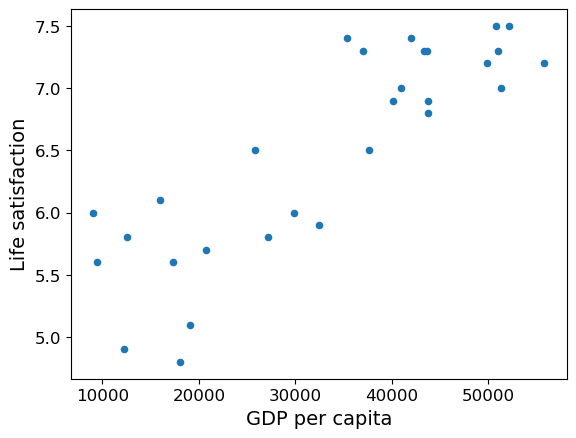

[[5.96242338]]
OK


In [4]:
# Code example
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

# Load the data
try:
    oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')
    gdp_per_capita = pd.read_csv(datapath + "gdp_per_capita.csv",thousands=',',delimiter='\t',
                             encoding='latin1', na_values="n/a")
except Exception as e:
    print(f"SWMAL NOTE: well, you need to have the 'datasets' dir in path, please unzip 'datasets.zip' and make sure that its included in the datapath='{datapath}' setting in the cell above..")
    raise e
    
# Prepare the data
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

# Visualize the data
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

# Select a linear model
model = sklearn.linear_model.LinearRegression()

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
X_new = [[22587]]  # Cyprus' GDP per capita
y_pred = model.predict(X_new)
print(y_pred) # outputs [[ 5.96242338]]

print("OK")

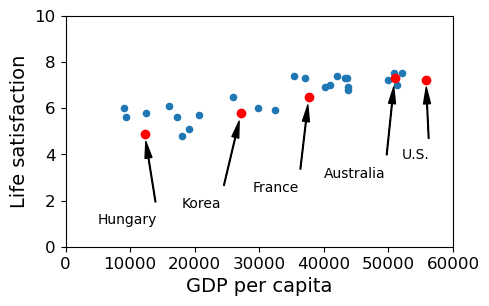

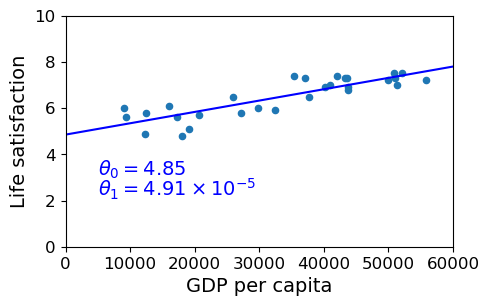

OK


In [5]:
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
#oecd_bli.head(2)

gdp_per_capita = pd.read_csv(datapath+"gdp_per_capita.csv", thousands=',', delimiter='\t',
                             encoding='latin1', na_values="n/a")
gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
gdp_per_capita.set_index("Country", inplace=True)
#gdp_per_capita.head(2)

full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita, left_index=True, right_index=True)
full_country_stats.sort_values(by="GDP per capita", inplace=True)
#full_country_stats

remove_indices = [0, 1, 6, 8, 33, 34, 35]
keep_indices = list(set(range(36)) - set(remove_indices))

sample_data = full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]
#missing_data = full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[remove_indices]

sample_data.plot(kind='scatter', x="GDP per capita", y='Life satisfaction', figsize=(5,3))
plt.axis([0, 60000, 0, 10])
position_text = {
    "Hungary": (5000, 1),
    "Korea": (18000, 1.7),
    "France": (29000, 2.4),
    "Australia": (40000, 3.0),
    "United States": (52000, 3.8),
}
for country, pos_text in position_text.items():
    pos_data_x, pos_data_y = sample_data.loc[country]
    country = "U.S." if country == "United States" else country
    plt.annotate(country, xy=(pos_data_x, pos_data_y), xytext=pos_text,
            arrowprops=dict(facecolor='black', width=0.5, shrink=0.1, headwidth=5))
    plt.plot(pos_data_x, pos_data_y, "ro")
#save_fig('money_happy_scatterplot')
plt.show()

from sklearn import linear_model
lin1 = linear_model.LinearRegression()
Xsample = np.c_[sample_data["GDP per capita"]]
ysample = np.c_[sample_data["Life satisfaction"]]
lin1.fit(Xsample, ysample)

t0 = 4.8530528
t1 = 4.91154459e-05

sample_data.plot(kind='scatter', x="GDP per capita", y='Life satisfaction', figsize=(5,3))
plt.axis([0, 60000, 0, 10])
M=np.linspace(0, 60000, 1000)
plt.plot(M, t0 + t1*M, "b")
plt.text(5000, 3.1, r"$\theta_0 = 4.85$", fontsize=14, color="b")
plt.text(5000, 2.2, r"$\theta_1 = 4.91 \times 10^{-5}$", fontsize=14, color="b")
#save_fig('best_fit_model_plot')
plt.show()

print("OK")

### Qa) The $\theta$ parameters and the $R^2$ score

#### Extracting the $\theta_0$ and $\theta$ coefficients
After fitting a linear regression model, parameters are read directly from the estimator:
- $\theta_0$ (intercept) → `intercept_`
- $\theta$ (coefficients) → `coef_` (one per feature)

**Sources**
- LinearRegression (attributes `coef_`, `intercept_`): <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html>

This parameter extraction is **separate from** any performance metric.

### What is the R² score?

$R^2$ measures how much variance in the target is explained by the model:

$$
\begin{array}{rcll}
    R^2 &=& 1 - \dfrac{u}{v} \\
    u   &=& \sum (y_{\text{true}} - y_{\text{pred}})^2   & \small \text{(residual sum of squares)} \\
    v   &=& \sum (y_{\text{true}} - \mu_{\text{true}})^2 & \small \text{(total sum of squares)}
\end{array}
$$

with $y_{\text{true}}$ the true targets, $y_{\text{pred}}$ the predictions, and $\mu_{\text{true}}$ the mean of the true targets.

**Interpretation**

In terms of perfectly predicting data, the R² tells us how well the data is fitted.  
Therefore, it is a measurement of fitness and goodness.  
The R² score ranges from 0 to 1, but when the residual sum of squares is greater than the total sum of squares, the score can be less than zero, and theoretically speaking infinitely low.  
While a score of 1 is considered perfect, a score equal to or greater than 0.7 is generally accepted.

**Sources**
- `r2_score` definition (negatives possible): <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html>

In [6]:
# Qa:
print(model.coef_)

print(model.intercept_)

[[4.91154459e-05]]
[4.8530528]


In [7]:
score = model.score(X, y)

print("R2 score for the model:", score)

R2 score for the model: 0.7344414355437031


### Qb) Using k-Nearest Neighbors

#### Changing the model and estimating for Cyprus
We start off with preparing the data:

In [8]:
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

X is our feature, and y is the target variable.


Now, we visualize the data by plotting it:

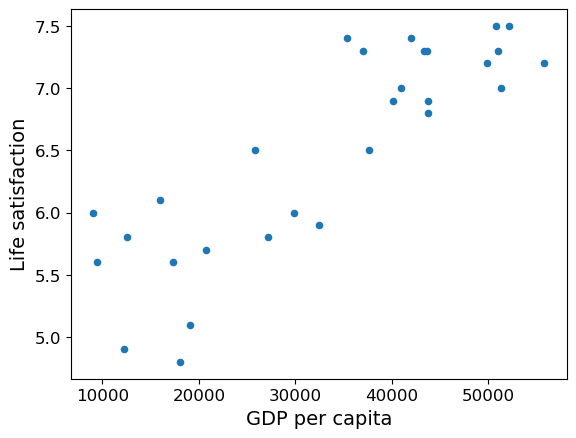

In [9]:
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

We then change to the KNN model:

In [10]:
# Using the KNeighborsRegressor instead of LinearRegression.
knn = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3) # Setting k=3, so we look at the 3 closest neighbors to make predictions
knn.fit(X, y)

KNeighborsRegressor(n_neighbors=3)

We can now use the trained KNN model to predict hte life satisfaction for Cyprus:

In [11]:
# Predict for Cyprus
cyprus_gdp = [[22587]]
cyprus_pred = knn.predict(cyprus_gdp)
print("Predicted life satisfaction for Cyprus:", cyprus_pred)

Predicted life satisfaction for Cyprus: [[5.76666667]]


This gives us the above output.

#### The score-method for KNN
The KNN (KNeighboursRegressor) calculates the score using the .score()-method.

#### Score used by `KNeighborsRegressor.score`
For regression, `.score(X, y)` returns **$R^2$** between $y$ and $\hat y=\text{predict}(X)$.  
For multi-output regression, scikit-learn reports a **uniform average** across targets.

**Sources**
- RegressorMixin `.score` (regression returns $R^2$): <https://scikit-learn.org/stable/modules/generated/sklearn.base.RegressorMixin.html>  
- `KNeighborsRegressor` API: <https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html>

#### Is it comparable to Linear Regression?
Yes. Both `LinearRegression.score` and `KNeighborsRegressor.score` report **$R^2$** on the given data, so their scores are directly comparable on the same dataset and split.

**Sources**
- `LinearRegression` API (inherits `RegressorMixin.score`): <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html>  
- RegressorMixin `.score` (R² for regressors): <https://scikit-learn.org/stable/modules/generated/sklearn.base.RegressorMixin.html>
"""

### Qc) Tuning Parameter for k-Nearest Neighbors and A Sanity Check

To perform a sanity check of the KNN prediction, we use the following code:

R^2 score for k=1: 1.0
R^2 score for k=2: 0.9091881835016248
R^2 score for k=5: 0.8023975402676358
R^2 score for k=10: 0.7833080605150065
R^2 score for k=20: 0.5523762709199536


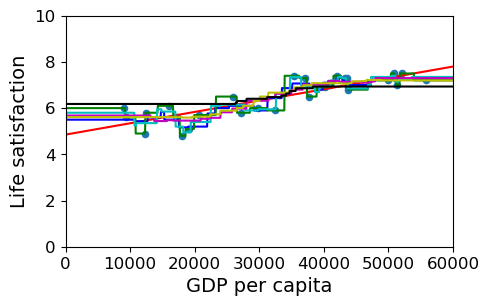

In [12]:
from sklearn.neighbors import KNeighborsRegressor


sample_data.plot(kind='scatter', x="GDP per capita", y='Life satisfaction', figsize=(5,3))
plt.axis([0, 60000, 0, 10])

# create an test matrix M, with the same dimensionality as X, and in the range [0;60000] 
# and a step size of your choice
m=np.linspace(0, 60000, 1000)
M=np.empty([m.shape[0],1])
M[:,0]=m

# from this test M data, predict the y values via the lin.reg. and k-nearest models
y_pred_lin = model.predict(M)
y_pred_knn = knn.predict(M)   # ASSUMING the variable name 'knn' of your KNeighborsRegressor 

# use plt.plot to plot x-y into the sample_data plot..
plt.plot(m, y_pred_lin, "r")
plt.plot(m, y_pred_knn, "b")

# For k = 1
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X, y)
y_pred_knn_1 = knn.predict(M)
plt.plot(m, y_pred_knn_1, "g")
# R score:
r2_score_knn_1 = knn.score(X, y)
print(f"R^2 score for k=1: {r2_score_knn_1}")

# For k = 2
knn = KNeighborsRegressor(n_neighbors=2)
knn.fit(X, y)
y_pred_knn_2 = knn.predict(M)
plt.plot(m, y_pred_knn_2, "c")
# R score:
r2_score_knn_2 = knn.score(X, y)
print(f"R^2 score for k=2: {r2_score_knn_2}")

# For k = 5
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X, y)
y_pred_knn_5 = knn.predict(M)
plt.plot(m, y_pred_knn_5, "m")
# R score:
r2_score_knn_5 = knn.score(X, y)
print(f"R^2 score for k=5: {r2_score_knn_5}")

# For k = 10
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X, y)
y_pred_knn_10 = knn.predict(M)
plt.plot(m, y_pred_knn_10, "y")
# R score:
r2_score_knn_10 = knn.score(X, y)
print(f"R^2 score for k=10: {r2_score_knn_10}")

# For k = 20
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X, y)
y_pred_knn_20 = knn.predict(M)
plt.plot(m, y_pred_knn_20, "k")
# R score:
r2_score_knn_20 = knn.score(X, y)
print(f"R^2 score for k=20: {r2_score_knn_20}")

plt.show()

We have compiled a table overviewing the colors and the k-value they represent:
| k value         | Color   | Description              |
|-----------------|---------|--------------------------|
| LinearRegression| red     | Linear Regression        |
| 3               | blue    | KNN (k=3, initial knn)   |
| 1               | green   | KNN (k=1)                |
| 2               | cyan    | KNN (k=2)                |
| 5               | magenta | KNN (k=5)                |
| 10              | yellow  | KNN (k=10)               |
| 20              | black   | KNN (k=20)               |

As shown on the graph above, for k=1, we get an R score of 1, and while this is considered perfect in many cases, it means that the model may be overfitting and might perform poorly on new data.

So, even though the R-score of 1 for k=1 looks promising, it is not the preferred estimator for the job. If we should test this model on new data, it will likely make poor predictions because it will simply copy the training set. A preferred model should balance fitting the training data and generalizing new data. A higher k-value will give us smoother predictions, even if the R-score is lower.

### Qd) Trying out a Neural Network

Predicted life satisfaction for Cyprus (MLP): 4.0767
R^2 score for MLP: -3.6741


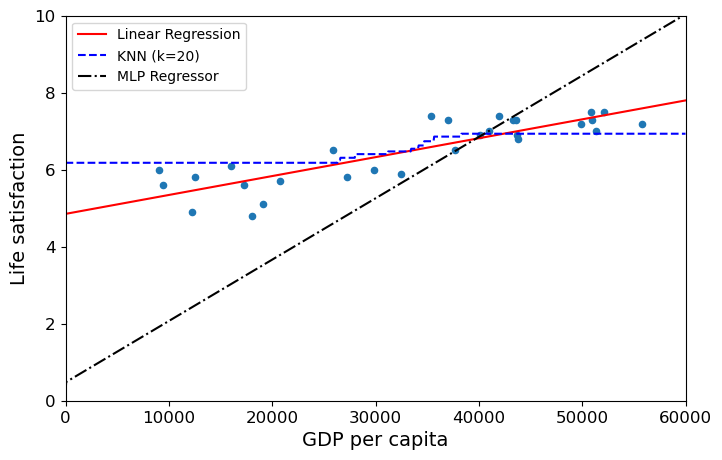

In [13]:
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt

mlp = MLPRegressor(
    hidden_layer_sizes=(10,), 
    solver='adam', 
    activation='relu', 
    tol=1E-5, 
    max_iter=100000, 
    verbose=False,
    random_state=42
)

mlp.fit(X, y.ravel())

y_pred_mlp_cyprus = mlp.predict([[22587]])
print(f"Predicted life satisfaction for Cyprus (MLP): {y_pred_mlp_cyprus[0]:.4f}")

r2_mlp = mlp.score(X, y)
print(f"R^2 score for MLP: {r2_mlp:.4f}")

m = np.linspace(0, 60000, 1000)
M = m.reshape(-1, 1)

y_pred_lin = model.predict(M)
y_pred_knn = knn.predict(M)
y_pred_mlp = mlp.predict(M)

sample_data.plot(kind='scatter', x="GDP per capita", y='Life satisfaction', figsize=(8,5))
plt.axis([0, 60000, 0, 10])
plt.plot(m, y_pred_lin, "r-", label="Linear Regression")
plt.plot(m, y_pred_knn, "b--", label="KNN (k=20)")
plt.plot(m, y_pred_mlp, "k-.", label="MLP Regressor")
plt.legend()
plt.show()

*Predicted life satisfaction for Cyprus (MLP):* 4.0767

$R^2$ score for MLP: -3.6741

A negative R2 score as seen above indicates that the model performs worse than simply predicting the mean of the target variable for all inputs.
In other words, the model's predictions are less accurate than a naive baseline.

# L02 - Modules and Packages in Python

#### Qa Load and test the `libitmal` module


In [14]:
import sys
print(sys.path)

['c:\\Users\\perhi\\anaconda3\\python313.zip', 'c:\\Users\\perhi\\anaconda3\\DLLs', 'c:\\Users\\perhi\\anaconda3\\Lib', 'c:\\Users\\perhi\\anaconda3', '', 'c:\\Users\\perhi\\anaconda3\\Lib\\site-packages', 'c:\\Users\\perhi\\anaconda3\\Lib\\site-packages\\win32', 'c:\\Users\\perhi\\anaconda3\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\perhi\\anaconda3\\Lib\\site-packages\\Pythonwin']


libitmal is placed in C:SWMAL\Journal\libitmal and is loaded by running the following code: 

In [ ]:
# Qa: Load and test the libitmal module
from libitmal import utils as itmalutils

itmalutils.TestAll()
print("Module path:", itmalutils.__file__)


# libitmal path is set with setx.exe PYTHONPATH "C:SWMAL\Journal\libitmal" followed by a reboot


TestPrintMatrix...(no regression testing)
X=[[   1.    2.]
   [   3. -100.]
   [   1.   -1.]]
X=[[ 1.  2.]
   ...
   [ 1. -1.]]
X=[[   1.
       2.    ]
   [   3.0001
    -100.    ]
   [   1.
      -1.    ]]
X=[[   1.    2.]
   [   3. -100.]
   [   1.   -1.]]
OK
TEST: OK
ALL OK
Module path: c:\Users\perhi\Documents\GitHub\SWMAL\Journal\libitmal\utils.py


The test returns the expected output

#### Qb Create your own module, with some functions, and test it

A folder named libitmal is created, containing the module TestModule along with an __init__.py file. This allows the module to be reused without keeping it in the same folder as the project file. Inside, a simple helloWorld() function is defined to print a greeting, and an addNumbers(a, b) function to return the sum of two numbers.

In [16]:
# Qb: Create module and test
from libitmal import TestModule as itmaltest

itmaltest.helloWorld()
result = itmaltest.addNumbers(5, 10)
print("Result of addition:", result)

Hej verden
Result of addition: 15


Here is the code for libitmal/TestModule.py:
```python
#!/usr/bin/env python3
def helloWorld():
        print("Hej verden")

def addNumbers(x, y):
        return x + y
```

And here is the libitmal/__init__.py:
```python
#!/usr/bin/env python3

# currently empty module init file!
from . import TestModule
```

#### Qc How do you 'recompile' a module?

Use importlib.reload() to force Jupyter to load the updated code:

In [17]:
# Qc: recompile the module
import importlib
import libitmal.TestModule

importlib.reload(libitmal.TestModule)

<module 'libitmal.TestModule' from 'c:\\Users\\perhi\\Documents\\GitHub\\SWMAL\\Journal\\libitmal\\TestModule.py'>

### Classes in Python

#### Qe Extend the class with some public and private functions and member variables

Python uses naming, not true access control. A single underscore (e.g., _temp) signals “internal by convention.” Double underscore (e.g., __secret) triggers name-mangling to _ClassName__secret, which discourages accidental access and similarly mangle methods like __hide().

Meaning of self
self is the instance the method operates on. obj.method(x) is translated to Class.method(obj, x), so the first parameter must receive the instance.

If you forget self
Defining a method without self and calling it on an instance passes the instance anyway and raises a TypeError.

## Source

> https://www.digitalocean.com/community/tutorials/understanding-class-and-instance-variables-in-python-3

Underneath in the code block the class has been exteneded with some public, private function and member variables to showcase the above explanation.

In [18]:
class MyClass:
    def __init__(self):
        self.public_counter = 0        
        self.__secret = "top secret"    

    def greet(self, name):             
        return f"Hello, {name}!"

    def myfun(self):
        self.myvar = "blah"              
        print(f"myvar={self.myvar}")

    def __ungreet(self, name):       
        return f"Goodbye, {name}!"

    def ungreeterino(self, name):       
        return self.__ungreet(name)

    def bad_method():                   
        return "I forgot self"

# Demo
o = MyClass()
print(o.greet("Mads"))              
print(o.ungreeterino("Daniel"))  
o.myfun()                         
try:
    o.bad_method()                   
except TypeError as e:
    print(e)
print(o._MyClass__secret)             


Hello, Mads!
Goodbye, Daniel!
myvar=blah
MyClass.bad_method() takes 0 positional arguments but 1 was given
top secret


The demo shows Python’s “privacy” is by naming: __secret and __ungreet are name-mangled (accessible as _MyClass__secret), while ordinary attributes like public_counter and myvar are public. self is the instance each method operates on; omitting it (as in bad_method) makes o.bad_method() raise a TypeError because Python still passes the instance as the first argument.

#### Qf Extend the class with a Constructor

A constructor and some methods are added to a new class using __init__.

In [19]:
# Qf Extend the class with a constructor
class MyClass:
   
    def myfun(self):
        self.myvar = "blah" # NOTE: a per class-instance variable.
        print(f"This is a message inside the class, myvar={self.myvar}.")

    # Added private and public methods
    def _my_private_method(self):
        print("This is a private method.")

    def my_public_method(self):
        print("This is a public method.")
        self._my_private_method() # self means this instance of MyClass, and we call the private method to demonstrate encapsulation.

    # Constructor
    def __init__(self, initial_value):
        self.myvar = initial_value
        print(f"Constructor called, myvar initialized to: {self.myvar}")

#### Qg Extend the class with a to-string function

A “to string” function is defined with __str__(self)

In [20]:
# Qg: Extend the class with a to-string func
class MyClass:
   
    def myfun(self):
        self.myvar = "blah" # NOTE: a per class-instance variable.
        print(f"This is a message inside the class, myvar={self.myvar}.")

    # Added private and public methods
    def _my_private_method(self):
        print("This is a private method.")

    def my_public_method(self):
        print("This is a public method.")
        self._my_private_method() # self means this instance of MyClass, and we call the private method to demonstrate encapsulation.

    # Constructor
    def __init__(self, initial_value):
        self.myvar = initial_value
        print(f"Constructor called, myvar initialized to: {self.myvar}")

    # to-string function
    def __str__(self):
        return f"MyClass with myvar = {self.myvar}"

# Using the to-string function
obj = MyClass("initial value")
print(obj)  # Calling the __str__ method


Constructor called, myvar initialized to: initial value
MyClass with myvar = initial value


# L02 - Cost function

#### Qa Given the following $\mathbf{x}^{(i)}$'s, construct and print the $\mathbf X$ matrix in python.

$$
  \begin{align*}
    \mathbf{x}^{(1)} &= \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix} \\
    \mathbf{x}^{(2)} &= \begin{bmatrix} 4 \\ 2 \\ 1 \end{bmatrix} \\
    \mathbf{x}^{(3)} &= \begin{bmatrix} 3 \\ 8 \\ 5 \end{bmatrix} \\
    \mathbf{x}^{(4)} &= \begin{bmatrix} -9 \\ -1 \\ 0 \end{bmatrix}
  \end{align*}
$$

To define the above matrix in python, we utilize the `np.array` function in `numpy` to define the values as a list of lists for each row in the matrix.

In [21]:
import numpy as np

y_true = np.array([1,2,3,4]) # NOTE:  you'll need this later

X = np.array([
    [1, 2, 3],
    [4, 2, 1],
    [3, 8, 5],
    [-9, -1, 0]
])

print(X)

[[ 1  2  3]
 [ 4  2  1]
 [ 3  8  5]
 [-9 -1  0]]


plement the $L_1$ and $L_2$ norms for vectors in python.rms for vectors in python.

Implementatin of L1- and L2 norms in pure python.


In [22]:
import math
def L1(vector):
    if vector.ndim != 1:
        raise ValueError("Input should be a 1D vector")
    sum = 0.0
    for i in range(len(vector)):
        sum += (vector[i]**2)**0.5

    return sum

def L2(vector):
    if vector.ndim != 1:
        raise ValueError("Input should be a 1D vector")
    
    sum = 0.0
    for i in range(len(vector)):
        sum += vector[i]**2
    return sum ** 0.5

def L2Dot(vector):
    return np.dot(vector.T,vector)**0.5

# TEST vectors: here I test your implementation...calling your L1() and L2() functions
tx=np.array([1, 2, 3, -1])
ty=np.array([3,-1, 4,  1])

expected_d1=8.0
expected_d2=4.242640687119285

d1=L1(tx-ty)
d2=L2(tx-ty)

print(f"tx-ty={tx-ty}, d1-expected_d1={d1-expected_d1}, d2-expected_d2={d2-expected_d2}")

eps=1E-9 
assert math.fabs(d1-expected_d1)<eps, "L1 dist seems to be wrong" 
assert math.fabs(d2-expected_d2)<eps, "L2 dist seems to be wrong" 

print("OK(part-1)")

d2dot=L2Dot(tx-ty)
print("d2dot-expected_d2=",d2dot-expected_d2)
assert math.fabs(d2dot-expected_d2)<eps, "L2Ddot dist seem to be wrong" 
print("OK(part-2)")

tx-ty=[-2  3 -1 -2], d1-expected_d1=0.0, d2-expected_d2=0.0
OK(part-1)
d2dot-expected_d2= 0.0
OK(part-2)


The functions return a difference of `0.0`, which means that the implementation is correct according to the test.

### Qc Construct the Root Mean Square Error (RMSE) function (Equation 2-1 [HOML]).

RMSE is used to se the difference between the predicted values and therefore the performance of the model that we are testing. The RMSE function always returns a non-negative number. The lower the number, the better the model fits the data. If its 0 the models predictions are exact.

The number can be as high as our `y_true` values.

In the code below the prediceted values are made with the `h(X)`function.

In [23]:
from math import fabs

# Dummy h function:
def h(X):    
    if X.ndim!=2:
        raise ValueError("excpeted X to be of ndim=2, got ndim=",X.ndim)
    if X.shape[0]==0 or X.shape[1]==0:
        raise ValueError("X got zero data along the 0/1 axis, cannot continue")
    return X[:,0]

def RMSE(X, y):
    if X.shape != y.shape:
        raise ValueError(f"X shape ({X.shape}) should be the same as y ({y.shape})")

    return L2(X-y) / np.sqrt(len(y))


# Calls your RMSE() function:
r=RMSE(h(X), y_true)

# TEST vector:
eps=1E-9
expected=6.57647321898295
print(f"RMSE={r}, diff={r-expected}")
assert fabs(r-expected)<eps, "your RMSE dist seems to be wrong" 

print("OK")

RMSE=6.576473218982953, diff=2.6645352591003757e-15
OK


#### Qd Similar construct the Mean Absolute Error (MAE) function (Equation 2-2 [HOML]) and evaluate it.

Implementation of the MAE equation:

$\text{MAE}(\mathbf{X}, h) = \frac{1}{m} \sum_{i=1}^{m} \left| h\!\left(\mathbf{x}^{(i)}\right) - y^{(i)} \right|$

In [24]:
def MAE(X, y):
    if X.shape != y.shape:
        raise ValueError(f"X shape ({X.shape}) should be the same as y ({y.shape})")
    return L1(X - y) / len(y)

# Calls your MAE function:
r=MAE(h(X), y_true)

# TEST vector:
expected=3.75
print(f"MAE={r}, diff={r-expected}")
assert fabs(r-expected)<eps, "MAE dist seems to be wrong" 

print("OK")

MAE=3.75, diff=0.0
OK


The MAE is 3.75 which gives us a difference of 0.0.

#### Qe Robust Code 

In our functions, we have made them more robust by adding error handling, such as using `ndim`, `ValueError` and `shape` to check if the parameters passed to the function is a vector or if it has the shape that we expect.

By doint the exercises on cost function a deeper understanding of the concepts are achieved.
It has also proven a good foundating in the python way of doing Machine Learning. By using the `fail fast` method, its possible to save much time not spending time on uneccesary computations that eventually would end in an error cased by wrong data or shape.

Its also very keen to be reusing robust code in Machine Learning. By having a collection of small, effective and safe code that can be referenced in the furture, is something to be appreciated.

# L02 - Dummy Classifier

In this section a dummy binary-classifier with a fit-predict interface is implemented

#### Qa  Load and display the MNIST data

The MNIST database consists of handwritten digits and has a training set of 60,000 examples. It’s retrieved from openml.org, and each digit in the dataset is a 28x28-pixel image.

The value of X[0] is: 5


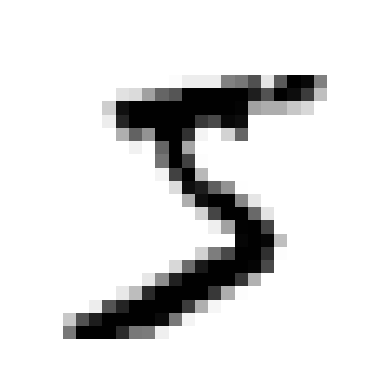

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import fetch_openml

def MNIST_GetDataSet():
    return fetch_openml('mnist_784', return_X_y=True, as_frame=False)

def MNIST_PlotDigit(data):
    import matplotlib
    import matplotlib.pyplot as plt
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")
    plt.show()


X, y = MNIST_GetDataSet()
print(f'The value of X[0] is: {y[0]}')
MNIST_PlotDigit(X[0])

The return_X_y parameter makes fetch_openml return a tuple (data, target) instead of a Bunch container, which otherwise contains more information about the dataset.
Once the dataset is retrieved, a single digit can be displayed with the MNIST_PlotDigit(data) function.

From the output above, you can see that the value of X[0] is 5 and the plot shows the handwritten digit located in that position.

#### Qb  Add a Stochastic Gradient Decent [SGD] Classifier

The dataset is split into a training and a test part so that testing and training aren’t done on exactly the same data, and an SGD Classifier is used to train the model on the data in the training part. This implementation can be seen below:

In [26]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.linear_model import SGDClassifier

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

shuffle_idx = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)


SGDClassifier(random_state=42)

Next, a true positive (a correctly classified digit), a false positive (a digit the model thinks is a 5 but is actually something else), and finally a true negative (a number correctly not classified as 5) are identified. The implementation is shown below.

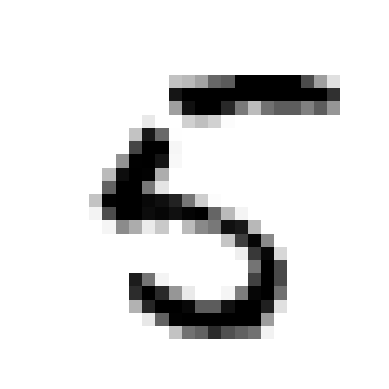

Predicted label: True


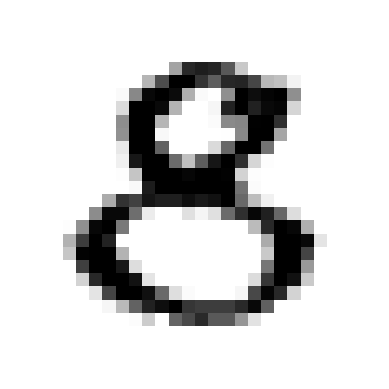

Predicted label: True


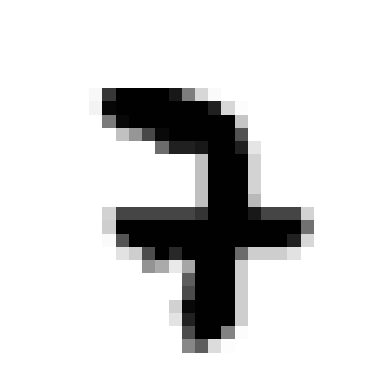

Predicted label: False


In [27]:
import numpy as np

# Predict labels
y_test_pred = sgd_clf.predict(X_test)

# Random true positive
true_pos_idx = np.where((y_test_5 == True) & (y_test_pred == True))[0]
rand_true_pos = np.random.choice(true_pos_idx)

# Random false positive
false_pos_idx = np.where((y_test_5 == False) & (y_test_pred == True))[0]
rand_false_pos = np.random.choice(false_pos_idx)

# Random true negative
true_neg_idx = np.where((y_test_5 == False) & (y_test_pred == False))[0]
rand_true_neg = np.random.choice(true_neg_idx)

# Plot a digit
MNIST_PlotDigit(X_test[rand_true_pos])
print("Predicted label:", y_test_pred[rand_true_pos])

MNIST_PlotDigit(X_test[rand_false_pos])
print("Predicted label:", y_test_pred[rand_false_pos])

MNIST_PlotDigit(X_test[rand_true_neg])
print("Predicted label:", y_test_pred[rand_true_neg])


_The code above was made with the help of ChatGPT_

The first picture is the true positive, the second is the false positive and the final is the true negative. This clearly visualizes how the model performs and where it makes mistakes.

#### Qc Implement a dummy binary classifier

Below is the implementation of a dummy classifier, which consists of a fit and a predict method. The dummy classifier only returns zeros when the predict function is used.

In [28]:
from sklearn.base import BaseEstimator

class DummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X),), dtype=bool)

In [29]:
from sklearn.metrics import accuracy_score

dummy = DummyClassifier()

dummy.fit(X_train, y_train_5)
y_dummy_pred = dummy.predict(X_test)
print(f"{y_dummy_pred}")

dummy_accuracy = accuracy_score(y_test_5, y_dummy_pred)
print(f"score for DummyClassifier: {dummy_accuracy:.2%}")

[False False False ... False False False]
score for DummyClassifier: 91.08%


### Qd Conclusion

The exercise provides a good understanding of how an estimator is used and how you can create your own classifier using `BaseEstimator` from the scikit-learn library. It also showed that it’s possible to create an estimator that doesn’t actually work (`DummyClassifier`) but still produces good results. It’s also very important to split your dataset so you don’t end up training and testing on the same chunk of data.

In [HOML] on page 107 there is the following quote:  
> “That’s right, it has over 90% accuracy! This is simply because only about 10% of the images are 5s, so if you always guess that an image is *not* a 5, you will be right about 90% of the time. Beats Nostradamus.”

This highlights how accuracy alone can be misleading and why proper evaluation metrics and validation are essential for building meaningful models.

If the dataset is skewed (e.g., 10/90), a majority-class baseline will score ≈90% by always predicting the majority class. That’s the accuracy paradox: high accuracy despite useless predictions; prefer recall/F1 or balanced accuracy on imbalanced data.

#### Source:
https://en.wikipedia.org/wiki/Accuracy_paradox


# L02 - Performance Metrics

## Performance Metrics

#### Qa Implement the Accuracy function and test it on the MNIST data.

An accuracy function implemented in pure python to calculate the accuracy of an algorithm. This function calculates the True Positives, True Negatives, False Positives and False Negatives.
The accuracy is calculated by dividing the sum of True Positive and True Negative with the total.

$\frac{(\sum TP + \sum TN)}{\sum Total}$

In [30]:
import math
from sklearn.metrics import accuracy_score


def MyAccuracy(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FP = 0
    TN = 0
    FN = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
            else:
                TN += 1
        else:
            if y_true[index] == True:
                FN += 1
            else:
                FP += 1

    sum_true = TP + TN
    sum = TP + FP + TN + FN

    return sum_true / sum
    
def TestAccuracy(y_true, y_pred):
    a0 = MyAccuracy(y_true, y_pred)
    a1 = accuracy_score(y_true, y_pred)

    print(f"\nMyAccuracy          ={a0}")
    print(f"scikit-learn a={a1}")

    if math.isclose(a0, a1, rel_tol=1e-9, abs_tol=1e-12):
        print("Results is perfect lesgoooo")
    else:
        print("Results is not good bro")

print(f"SGD Classifier accuracy:")
TestAccuracy(y_test_5, y_test_pred)
print()
print(f"Dummy Classifier accuracy:")
TestAccuracy(y_test_5, y_dummy_pred)

SGD Classifier accuracy:

MyAccuracy          =0.9675
scikit-learn a=0.9675
Results is perfect lesgoooo

Dummy Classifier accuracy:

MyAccuracy          =0.9108
scikit-learn a=0.9108
Results is perfect lesgoooo


Made with help from [ChatGPT](https://chatgpt.com/share/68c3de9f-237c-8008-9c33-f02bfa575d27)

#### Qb Implement Precision, Recall and $F_1$-score and test it on the MNIST data for both the SGD and Dummy classifier models


The implementation if Precision, Recall and $F_1$-score.
The 3 functions is calculated as seen in Nomenclature for the confusion matrix in MAL lection 2 (Slide 27) [Frigaard, 2025](https://itundervisning.ase.au.dk/SWMAL/L02/lesson02.pdf)

Precision:
$p = \frac{TP}{TP+FP}$

Recall:
$r=\frac{TP}{TP+FN}$

$F_1$-score:
$F_1=\frac{2pr}{p+r}$

In [31]:
def MyPrecision(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FP = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
        else:
            if y_true[index] == False:
                FP += 1

    sum = TP + FP

    if not sum:
        return 0

    # Accuracy
    return  TP / sum

def MyRecall(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FN = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
        else:
            if y_true[index] == True:
                FN += 1

    sum = TP + FN

    if not sum:
        return 0

    # Accuracy
    return  TP / sum
    
def MyF1Score(y_true, y_pred):
    precision = MyPrecision(y_true, y_pred)
    recall = MyRecall(y_true, y_pred)

    sum = precision + recall

    if not sum:
        return 0
    
    return 2 * (recall * precision) / sum

# TODO: your test code here!


#### Qc The Confusion Matrix

In [32]:
from sklearn.metrics import confusion_matrix

M_dummy = confusion_matrix(y_test_5, y_test_pred)
M_SDG = confusion_matrix(y_test_5, y_test_pred)

print("Confusion matrix for dummy")
print(M_dummy)

print()

print("Confusion matrix for SGD")
print(M_SDG)

Confusion matrix for dummy
[[8920  188]
 [ 137  755]]

Confusion matrix for SGD
[[8920  188]
 [ 137  755]]


In the above, the cells are formatted in:
| TP | FP |
|----|----|
| FN | TN |


#### Qd A Confusion Matrix Heat-map

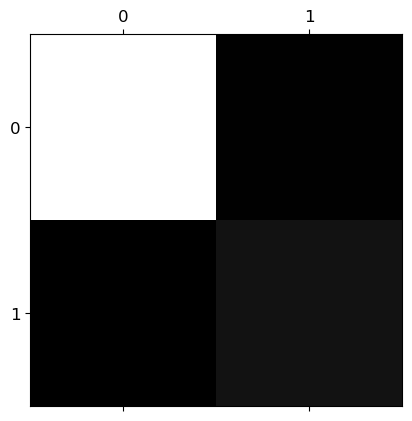

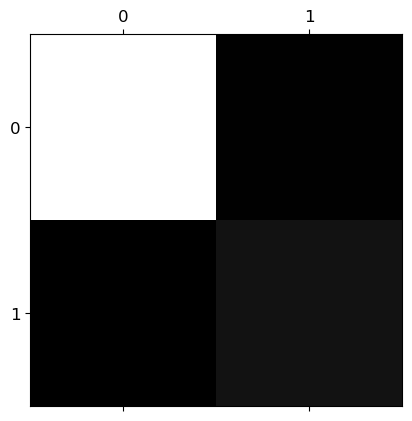

In [33]:
plt.matshow(M_dummy, cmap=plt.cm.gray)
plt.show()

plt.matshow(M_SDG, cmap=plt.cm.gray)
plt.show()

In the heat maps above, its seen that the more white the box is, the more elements are in that category. From the two above, its possible to see that the two models behave somewhat the same. But multiple members of the group is colorblind, therefore this is maybe not the best way to analyze data. But for someone that is not colorblind, this would be excellent.

### Qe Conclusion

This exercise have us a better understanding of how to measure the performance of machine learning algorithms and how to implement it in Python. By working further with the MNIST dataset, we learned more about the Scikit package and how to work with the different metrics like accuracy, precision, recall and F1-score.